# Week 2 - Part 1

Study plan:
- GitHub review
- Homework review
- Recap of last week
- Pandas' dataframe object
- data acquisition / loading data into a Pandas' dataframe
- preview of Matplotlib



| Weeks | Course objectives |
|--------------|---------|
| week 1,2 | Understand, select when and how to use the *main Python libraries* for data analysis |
| week 2,3,4 | Display an advanced understanding of *data acquisition* |
| week 2,3,4,5 | Explore a dataset and apply data quality techniques |
| week 3 | Perform data transformation for machine learning |
| week 2,3 | Produce statistical data analysis |
| week 2,3 | Create data visualizations |
| week 3,4 | Reflect on the characteristics and suitability of a dataset for ML |




# GitHub review

One day 1, each course participant was given access to their own personal GitHub repository for the DAF course.

This repository was generated from a "parent" repository which already contained the Week1.ipynb file.

This initial version is illustrated on the left side of the diagram with a blue frame.

During the 1st course evening, each participant has launched a codespace from their GitHub repository.

A unique name for your codespace was generated. For instance, my codespace was named "unique space journey".

Codespace provides a complete development environment from which you can start coding, adding files, adding data resources, etc.

In order to "save" your work, you need to:

- click on the "Github" icon on the left side
- add a comment such as "saving work in progress class #2"
- select "commit and push"


These 3 steps ensure that your changes are save back to your GitHub repository.

When a new homework file is added to the parent repository - i.e. the repository that was used as a template for this DAF course - a message appears in your GitHub repository indicating that your personal repository is now "behind".


What happened?

You are both "ahead" and "behind".

How can that be?

You are "ahead" because you have added your own files to the repository.

You are "behind" because the parent repository was updated with a new homework file.

You can "merge" the content from the parent directory. So that you get both your work as well as the new content.




  <img src="https://nico.nexgate.ch/images/zhaw/github.jpeg" width=600 alt="github" />

#### Resolving quadratic equations

$a x^2+b x+c=0$

First, calculate $\Delta = b^2-4ac$

If $\Delta < 0$ return "no solution"$

If $\Delta > 0$ return 2 solutions $x=\frac{-b\pm\sqrt{b^2-4ac}}{2a}$

Otherwise, if $\Delta = 0$ then the solution is $x=\frac{-b}{2a}$

The function below contains code to resolve a quadratic equation.

IMPORTANT:

- in Python, after an IF statement, you need to indent the next line.

```Python
if delta>0:
        sol1= (-b + math.sqrt(delta))/(2*a)
        sol2= (-b - math.sqrt(delta))/(2*a)
```

is correct because you see a tab (indentation) before ```sol1= ....```

but,

```Python
if delta>0:
sol1= (-b + math.sqrt(delta))/(2*a)
sol2= (-b - math.sqrt(delta))/(2*a)
```

is not correct.

In [2]:
import math

def resolve_equation(a,b,c):


    delta= b * b - 4 * a * c
    print("delta is ",delta)
    
    if delta>0:
        
        sol1= (-b + math.sqrt(delta))/(2*a)
        sol2= (-b - math.sqrt(delta))/(2*a)
        return (sol1,sol2)
    elif delta==0:
        sol = -b / (2 * a)
        return sol
    else:
        return None


🥦  <font color='red'>TODO</font>: Test your function with different values of a,b,c

In [3]:
# add your code here
print(resolve_equation(1, -3.4, 2.2))  # Should return (2.0, 1.0)


delta is  2.759999999999998
(2.530662386291807, 0.8693376137081927)


## Pandas DataFrame review

A DataFrame is a table of data with rows and columns. It is the workhorse of data science.

In its most simple form, you can think of a DataFrame as an Excel worksheet.

<img src="https://nico.nexgate.ch/images/excel_vs_df.jpg" width='80%' alt="excel" />

## DataFrame with multi-level indexes

In [4]:
import numpy as np
import pandas as pd

Let's create an array of numbers from -10 to 10 with a step increment of 1 using numpy linespace

In [5]:
x = np.linspace(-10,10,21)
x

array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
         1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.])

Let's create a multi-index dataframe using the range of numbers contained in the variable x

For each value of x, we add the columns:

- Values
    - squared x
- Trigonometry
    - sin x
    - cos x

In [6]:

# create a 2-level (MultiIndex) column dataframe using existing variables: x, ENROLMENTS, participants
mi = pd.MultiIndex.from_tuples([
    ('values', 'x'),
    ('values', 'x_squared'),
    ('trig', 'sin'),
    ('trig', 'cos')
])

data = np.column_stack([
    x,
    x**2,
    np.sin(x),
    np.cos(x)
])

df_multi = pd.DataFrame(data, columns=mi)

df_multi

values                trig          
        x x_squared       sin       cos
0   -10.0     100.0  0.544021 -0.839072
1    -9.0      81.0 -0.412118 -0.911130
2    -8.0      64.0 -0.989358 -0.145500
3    -7.0      49.0 -0.656987  0.753902
4    -6.0      36.0  0.279415  0.960170
5    -5.0      25.0  0.958924  0.283662
6    -4.0      16.0  0.756802 -0.653644
7    -3.0       9.0 -0.141120 -0.989992
8    -2.0       4.0 -0.909297 -0.416147
9    -1.0       1.0 -0.841471  0.540302
10    0.0       0.0  0.000000  1.000000
11    1.0       1.0  0.841471  0.540302
12    2.0       4.0  0.909297 -0.416147
13    3.0       9.0  0.141120 -0.989992
14    4.0      16.0 -0.756802 -0.653644
15    5.0      25.0 -0.958924  0.283662
16    6.0      36.0 -0.279415  0.960170
17    7.0      49.0  0.656987  0.753902
18    8.0      64.0  0.989358 -0.145500
19    9.0      81.0  0.412118 -0.911130
20   10.0     100.0 -0.544021 -0.839072

Let's take a look at the columns' index

In [7]:
df_multi.columns

MultiIndex([('values',         'x'),
            ('values', 'x_squared'),
            (  'trig',       'sin'),
            (  'trig',       'cos')],
           )

## Creating a dataframe form a dictionary

Although most of the time, you will load data from a csv file or an excel file or a web site, it is also possible to use a dictionary object to create a dataframe.

In week1, we had created a variable agre_dict which contained the ages of people.

We will now create a bigger dictionary object and we will then create a dataframe from the dictionaty.

In [8]:
employee_data = {
        'id':['2345','4564','1117','8734','2311','8790'],
        'name':['Remia','Alex','Julia','Matthias','Caroline','Georg'],
        'age':[23,19,37,52,46,55],
        'work':['Lonza','ZHAW','ZHAW','Alexion','Alexion','Sonova'],
        'savings':[45000,2300,165000,254000,420000,185000],
        'checking':[3450,6500,7340,13500,12050,6540]}

In [9]:
df = pd.DataFrame(employee_data)

In [10]:
df

,id,name,age,work,savings,checking
0,2345,Remia,23,Lonza,45000,3450
1,4564,Alex,19,ZHAW,2300,6500
2,1117,Julia,37,ZHAW,165000,7340
3,8734,Matthias,52,Alexion,254000,13500
4,2311,Caroline,46,Alexion,420000,12050
5,8790,Georg,55,Sonova,185000,6540


# Introduction to data quality checks

In most data science projects, the work pipeline follows the 12 steps below.

We have just created a dataset above. 

We will now focus on the first steps involved in assessing the quality of your data.

These systematic steps are applicable to most data analysis project.



1. Problem Definition

- Clearly defining the problem to be solved and understanding the business or research question.

2. Data Collection

- Data Sources Identification: Finding relevant data sources, such as databases, APIs, web scraping, or third-party datasets.
- Data Gathering: Collecting raw data through various means and ensuring proper storage for further analysis.

3. Data Cleaning and Preprocessing

- Data Quality Assessment: Checking for missing, incorrect, or inconsistent data.
- Handling Missing Values: Imputing, filling, or removing missing data based on context.
- Outlier Detection: Identifying and addressing outliers that could skew analysis.
- Data Type Conversion: Ensuring all data types are correct and compatible with analysis tools.
- Normalization and Scaling: Adjusting the scale of features for algorithms sensitive to magnitude.

4. Exploratory Data Analysis (EDA)

- Descriptive Statistics: Generating basic statistics to understand distributions and relationships.
- Visualization: Using graphs and charts to explore patterns, correlations, and trends.
- Hypothesis Generation: Formulating hypotheses based on initial findings.

5. Feature Engineering and Selection

- Feature Creation: Developing new variables that could improve model performance (e.g., date transformations, text - processing).
- Feature Selection: Choosing the most relevant variables to reduce dimensionality and improve model efficiency.
- Encoding Categorical Data: Converting categorical data into numerical format using methods like one-hot encoding or label encoding.

6. Model Selection
- Choosing Algorithms: Selecting appropriate machine learning or statistical models based on the problem type (e.g., regression, classification, clustering).
- Baseline Models: Implementing simple models as a benchmark for comparison.

7. Model Training and Tuning

- Splitting Data: Dividing the data into training, validation, and test sets to prevent overfitting.
- Training Models: Fitting the chosen algorithms to the training data.
- Hyperparameter Tuning: Using techniques like Grid Search or Random Search to optimize model performance.
Cross-Validation: Applying cross-validation to ensure model robustness and generalizability.

8. Model Evaluation

- Performance Metrics: Evaluating models using appropriate metrics such as accuracy, precision, recall, F1-score for classification tasks, or RMSE and MAE for regression tasks.
- Visual Diagnostics: Plotting learning curves, confusion matrices, or ROC curves to interpret model behavior.
Comparison: Assessing different models and selecting the best-performing one.

9. Model Deployment

- Packaging Model: Preparing the model to be deployed in production, which may involve exporting code, saving model weights, or creating APIs.
- Integration with Systems: Embedding the model into applications or data pipelines.
- Monitoring: Setting up monitoring to track model performance over time, detecting data drift, and retraining if necessary.

10. Maintenance and Monitoring

- Ongoing Evaluation: Regularly monitoring the model's accuracy and performance metrics in production.
- Feedback Loop: Incorporating user or system feedback for continual improvements.
- Retraining: Updating the model with new data to keep it relevant and accurate.

11. Documentation and Reporting

- Comprehensive Documentation: Creating detailed reports on data preprocessing, model selection, results, and insights.
- Stakeholder Communication: Presenting findings and results in a clear, understandable format for stakeholders and decision-makers.

12. Iterative Refinement


## Attributes and methods of a pandas dataframe for QA

Let's discover the main **attributes** and **methods** (or functions) you can call on a dataframe object to get basic information about a dataset.

The difference between an attribute and a method is that an attribute does not use parameters while a method may have parameters and is therefor called with ().

```
df.attribute_x  
df.method(parameter1, parameter2, ...)
```

🥦 <font color='red'>TODO</font>: Try the attributes and methods in the cells below.



In [11]:
# shape
df.shape

(6, 6)

In [12]:
# columns
df.columns

Index(['id', 'name', 'age', 'work', 'savings', 'checking'], dtype='object')

In [13]:
# dtypes
df.dtypes

id          object
name        object
age          int64
work        object
savings      int64
checking     int64
dtype: object

In [14]:
# head(2)
df.head(2)

,id,name,age,work,savings,checking
0,2345,Remia,23,Lonza,45000,3450
1,4564,Alex,19,ZHAW,2300,6500


In [15]:
# tail(2)
df.tail(2)

,id,name,age,work,savings,checking
4,2311,Caroline,46,Alexion,420000,12050
5,8790,Georg,55,Sonova,185000,6540


In [16]:
# sample(2)
df.sample(2)

,id,name,age,work,savings,checking
2,1117,Julia,37,ZHAW,165000,7340
3,8734,Matthias,52,Alexion,254000,13500


🌶️ Add a parameter ```random_sate=1``` to df.sample()

In [17]:
df.sample(random_state=66, n=2)

,id,name,age,work,savings,checking
0,2345,Remia,23,Lonza,45000,3450
1,4564,Alex,19,ZHAW,2300,6500


In [18]:
# to extract a column from a dataframe, simply type the df.name_of_the_column
df.savings.mean

<bound method Series.mean of 0     45000
1      2300
2    165000
3    254000
4    420000
5    185000
Name: savings, dtype: int64>

Sometimes it is not possible to use df.name_of_the_column

Let's load a boat permit dataset

In [19]:
df_boats = pd.read_csv('https://query.data.world/s/ggc6s5p6dxwzy4c2dyygv2czjrm7uk')

df_boats.head(4)

,Year,Basin,Permits Issued,Seasonal Tags,Temporary Tags,Canoes,Kayaks,Rowboats,Sailboats,Sculls
0,2013,Cannonsville,103,58,45,34,53,11,4,1
1,2013,Neversink,122,63,59,20,91,5,6,0
2,2013,Pepacton,457,219,238,120,311,15,10,1
3,2013,Schoharie,62,42,20,14,40,1,4,3



❓ Why is it not possible to retrieve all column data using boats.name_of_a_column?

In this situation, we can also retrieve values from a column by using a square bracket notation:

```
df['name of my column']
```

🥦 <font color='red'>TODO</font>: Using the df['name of my column'] notation, retrieve the values of the "Permits Issued" column from the df_boats dataframe.

In [20]:
df_boats['Permits Issued']

0     103
1     122
2     457
3      62
4     744
5      92
6     104
7     535
8      62
9     793
10     72
11     95
12    527
13     56
14    750
15     71
16    113
17    510
18     62
19     87
20     77
21    461
22     53
Name: Permits Issued, dtype: int64

🥦 <font color='red'>TODO</font>: Going back to the df dataframe object, try the methods in the cells below.

In [21]:
# info()
df_boats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Year            23 non-null     int64 
 1   Basin           23 non-null     object
 2   Permits Issued  23 non-null     int64 
 3   Seasonal Tags   23 non-null     int64 
 4   Temporary Tags  23 non-null     int64 
 5   Canoes          23 non-null     int64 
 6   Kayaks          23 non-null     int64 
 7   Rowboats        23 non-null     int64 
 8   Sailboats       23 non-null     int64 
 9   Sculls          23 non-null     int64 
dtypes: int64(9), object(1)
memory usage: 1.9+ KB


In [22]:
# describe()
df_boats.describe()

,Year,Permits Issued,Seasonal Tags,Temporary Tags,Canoes,Kayaks,Rowboats,Sailboats,Sculls
count,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000
mean,2014.869565,261.217391,130.173913,131.043478,68.913043,175.391304,12.478261,3.913043,0.521739
std,1.423962,263.601103,119.011326,146.449023,72.642908,177.451079,12.093836,5.493079,1.201119
min,2013.000000,53.000000,30.000000,9.000000,9.000000,32.000000,1.000000,0.000000,0.000000
25%,2014.000000,71.500000,41.500000,24.000000,17.500000,46.000000,2.500000,1.000000,0.000000
50%,2015.000000,103.000000,58.000000,45.000000,27.000000,70.000000,10.000000,2.000000,0.000000
75%,2016.000000,485.500000,221.000000,242.500000,116.500000,339.500000,16.000000,4.000000,0.500000
max,2017.000000,793.000000,382.000000,436.000000,220.000000,518.000000,42.000000,24.000000,5.000000


❓ Why are the 'id', 'name' and 'work' columns now shown when we use the describe() method?

In [23]:
df_boats

,Year,Basin,Permits Issued,Seasonal Tags,Temporary Tags,Canoes,Kayaks,Rowboats,Sailboats,Sculls
0,2013,Cannonsville,103,58,45,34,53,11,4,1
1,2013,Neversink,122,63,59,20,91,5,6,0
2,2013,Pepacton,457,219,238,120,311,15,10,1
3,2013,Schoharie,62,42,20,14,40,1,4,3
4,2013,Totals,744,382,362,188,495,32,24,5
5,2014,Cannonsville,92,41,51,32,44,14,2,0
6,2014,Neversink,104,57,47,23,70,8,3,0
7,2014,Pepacton,535,219,316,155,356,17,7,0
8,2014,Schoharie,62,40,22,10,48,3,1,0
9,2014,Totals,793,357,436,220,518,42,13,0


In [24]:
# sort_values(), inplace option
df_boats.sort_values(by='Permits Issued', inplace=True)

In [25]:
# extract values from 1 column
# https://pandas.pydata.org/docs/reference/series.html
df.id

0    2345
1    4564
2    1117
3    8734
4    2311
5    8790
Name: id, dtype: object

In [26]:
# value_counts()
df.value_counts()
df.work.value_counts(normalize=True)

work
ZHAW       0.333333
Alexion    0.333333
Lonza      0.166667
Sonova     0.166667
Name: proportion, dtype: float64

value_counts() returns the number of times each value appears in the dataset.

It is also possible **normalize** the results using
```Python
.value_counts(normalize=True)
```

❓ Why is sometimes useful to normalize the results?



## Pirates dataset

Let's look at a Pirates dataset to compare **value counts** vs. **normalized value counts**

In [28]:
df_pirates = pd.read_excel('https://query.data.world/s/vki7ozyt4unbgbzu4jf6maksivvfhi')
df_pirates.to_csv('../data/pirates.csv')

In [28]:
df_pirates.head()

,PirateID,FirstName,LastName,Origin,Teeth,Limbs,PositionID,ShipID
0,1,Francois,Nob,England,25,4.0,4,45
1,2,Pete,Smee,Spain,8,3.0,7,14
2,3,Bose,Threepwood,Philippines,16,4.0,3,33
3,4,Mark,Fozz,Ireland,23,4.0,8,44
4,5,Jeff,Smithe,Australia,9,2.0,1,36


We are intersted to check if it was common for a pirate to lose an arm or a leg, so we can look at the distribution of pirates with 4 limbs (2 arms and 2 legs), vs. only 3 limbs, 2 limbs, 1 limb or no limb left.

<img src="https://nico.nexgate.ch/images/random_pirates.png" width='50%' alt="excel" />

In [29]:
df_pirates.Limbs.value_counts()

Limbs
4.0    531
2.0     67
0.0     65
1.0     56
3.0     33
2.5      1
Name: count, dtype: int64

In [30]:
df_pirates.Limbs.value_counts(normalize=True).round(3)*100

Limbs
4.0    70.5
2.0     8.9
0.0     8.6
1.0     7.4
3.0     4.4
2.5     0.1
Name: proportion, dtype: float64

Using normallized data, we get percentages (as opposed to counts). Percentages are easier to compare than random quantities and they are also easier to visualize.

<img src="https://nico.nexgate.ch/images/pirates.png" width='80%' alt="excel" />



🌶️🌶️ Optional reading

If you are interested in machine learning, normalization will become an important topic to transform features - features are data elements used by a machine learning model - before training a machine learning model.

https://developers.google.com/machine-learning/data-prep/transform/normalization


### Selecting and extracting columns from a dataset

Instead of extracting 1 column of data, it is very common to extract several columns from a dataset.

Instead of passing a single column name:
```Python
df['my column name']
```
we can pass a list of columns:
```Python
df[list of columns]
```
In Python, a list is defined using square brackets, for instance, we can define a list of columns as:
```Python
['id','name','age']
```
Finally, we can extract a slice of a dataframe made of several columns
```Python
df[['id','name','age']]
```

In [31]:
# extracting a subset of columns
df_pirates[['FirstName','LastName']]

,FirstName,LastName
0,Francois,Nob
1,Pete,Smee
2,Bose,Threepwood
3,Mark,Fozz
4,Jeff,Smithe
...,...,...
748,Bose,Jenkins
749,Davy,Allen
750,Red-handed,Red-beard
751,Dan,de-Mutilator


In [32]:
# min, max, sum, mean, median, etc.
# https://pandas.pydata.org/docs/reference/frame.html#
df_pirates.Limbs.mean()

np.float64(3.2078353253652057)

In [33]:
# new column
df_pirates["Bounty"] = 100

In [34]:
# copy
df_pirates_backup = df_pirates.copy()


### Use case, house electric consumption data

In [35]:
df_house = pd.read_csv('https://download.data.world/s/tbff7hrltqkyn4zrvzwd3ww4s5b2q5')

🥦 <font color='red'>TODO</font>: Find the size of a dataframe.

In [36]:

df_house.size

1042560

🥦 <font color='red'>TODO</font>: Preview the first 5 rows, last 5 rows and a random sample of 5 rows of the DataFrame using the following funcitons on the DataFrame:

- head(n)
- tail(n)
- sample(n)

where n indicates the number of rows

In [37]:
df_house.head(5)
df_house.tail(5)
df_house.sample(5)

,date,time,voltage,global_intensity
181940,2007-05-07,08:20:00,235.02,7.2
102085,2007-03-12,21:25:00,236.77,16.6
16611,2007-01-12,12:51:00,242.49,1.4
232525,2007-06-11,11:25:00,239.88,0.4
58291,2007-02-10,11:31:00,239.71,5.4


🥦 <font color='red'>TODO</font>: Using the electric_power  function add a new column "power" to the df_house DataFrame.

Hint,

```python
df_house['power'] = ...
```

In [38]:
# add your code here
df_house["power"]= df_house["voltage"] * df_house.global_intensity


### Import your own dataset


🌶️ <font color='red'>TODO</font>:

- if you are using GitHub codespace, drag and drop your csv or excel file directly into your GitHub repository or directly into Codespace.
- if you use a local installation of Python (anaconda or conda): copy your data file (.csv or .xls) in directory where you have this notebook
- use pd.read_csv() or pd.read_excel() to load your data


Load the dataset contained in the file ```nic ingredients v1.csv``` contained in the data folder and assign the results to the variable ```df_ingredients```

In [39]:
# df_ingredients 
df_ingredients = pd.read_csv("../data/nic ingredients v1.csv")

Load the data from the dataset contained in the file ```nic - HRDataset.csv```in the data folder and assign it to the variable ```df_hr```

In [40]:
# df_hr
df_hr = pd.read_csv("../data/nic - HRDataset.csv")


In [41]:

df_hr


,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306,"Woodson, Jason",10135,0,0,1,1,5,3,0,65893,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,4.07,4,0,2/28/2019,0,13
307,"Ybarra, Catherine",10301,0,0,0,5,5,1,0,48513,...,Brannon Miller,12.0,Google Search,PIP,3.20,2,0,9/2/2015,5,4
308,"Zamora, Jennifer",10010,0,0,0,1,3,4,0,220450,...,Janet King,2.0,Employee Referral,Exceeds,4.60,5,6,2/21/2019,0,16
309,"Zhou, Julia",10043,0,0,0,1,3,3,0,89292,...,Simon Roup,4.0,Employee Referral,Fully Meets,5.00,3,5,2/1/2019,0,11


In [42]:
df_xml = pd.read_xml("../data/2025.11.05 11.20-TRAINING.xml")

C:\Users\pasca\AppData\Local\Temp\ipykernel_16564\2658702255.py:1: FutureWarning: Passing literal xml to 'read_xml' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df_xml = pd.read_xml("../data/2025.11.05 11.20-TRAINING.xml")


ImportError: lxml not found, please install or use the etree parser.

# Checkpoints

- How to define a function in Python
- What is a control flow
- What is a Pandas dataframe
- What is EDA (Exploratory Data Analysis)
- Understand the basic data quality checks 
- Name the basic commands to perform quality assurance steps after loading your data into a dataframe in Python?

# Optional material

## 🌶️ Magic Commands

* Set of commands that are not part of Python itself but can be used within Jupyter Notebook either to connect with your environment, configure the behaviour of your notebook or produce performance statistics on your code.
* use the % prefix, e.g. %hist
* In this course we will mostly use %matplotlib inline (week 3)

In [ ]:
# create a list of 100000 random numbers
random_numbers = np.random.rand(100000)
random_numbers

array([0.50938547, 0.46680907, 0.84422552, ..., 0.39118027, 0.52925168,
       0.01123264], shape=(100000,))

In [ ]:
%%timeit
random_numbers.sort(axis=0)

1.82 ms ± 28 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [ ]:
random_numbers.sort()
random_numbers

array([1.12742444e-05, 1.30328989e-05, 1.80075155e-05, ...,
       9.99905268e-01, 9.99930438e-01, 9.99988639e-01], shape=(100000,))

In [ ]:
%matplotlib inline

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## Additional data generation tools

**Generating a list of random numbers**

np.random.randn generates an array of shape (d0, d1, ..., dn), filled with random floats sampled from a univariate “normal” (Gaussian) distribution of mean 0 and variance 1

**Cummulative sums**

 numpy.cumsum(my_list) returns the cumulative sum of the elements in my_list

In [ ]:
my_list = np.random.randn(50)
my_list

array([-1.08336404,  1.99582861, -1.37021081, -0.19418845,  0.77234831,
        0.48535156, -0.0792681 , -0.80964787, -0.75830173,  0.38209964,
        0.18386545, -0.218663  ,  1.28645042, -0.85507785, -0.49209363,
       -0.38603671,  0.47991315, -0.20591269,  0.99765995,  0.29038519,
        1.79798292, -0.64005805,  1.63107235, -2.24158584, -0.1127393 ,
       -0.53697753, -1.21470253, -0.35092211,  0.1183416 , -1.65343405,
        0.61750863,  0.90500879,  0.1774373 , -0.90706687,  1.26605868,
        1.75342075, -0.24971053,  0.60353453, -0.05059237, -0.45963933,
        0.91784518,  0.78540667, -0.46310044, -0.43053125, -0.09997781,
        1.10729748,  1.70870177,  0.00774402,  0.30442136, -1.98378494])

In [ ]:
cum_sum = my_list.cumsum()
cum_sum

array([-1.08336404,  0.91246457, -0.45774624, -0.65193469,  0.12041362,
        0.60576517,  0.52649707, -0.28315081, -1.04145254, -0.6593529 ,
       -0.47548746, -0.69415045,  0.59229997, -0.26277787, -0.7548715 ,
       -1.14090821, -0.66099506, -0.86690775,  0.1307522 ,  0.4211374 ,
        2.21912032,  1.57906227,  3.21013462,  0.96854878,  0.85580948,
        0.31883195, -0.89587058, -1.24679269, -1.12845108, -2.78188514,
       -2.1643765 , -1.25936771, -1.08193041, -1.98899728, -0.7229386 ,
        1.03048215,  0.78077162,  1.38430615,  1.33371378,  0.87407445,
        1.79191963,  2.5773263 ,  2.11422586,  1.68369461,  1.58371681,
        2.69101428,  4.39971605,  4.40746008,  4.71188143,  2.7280965 ])

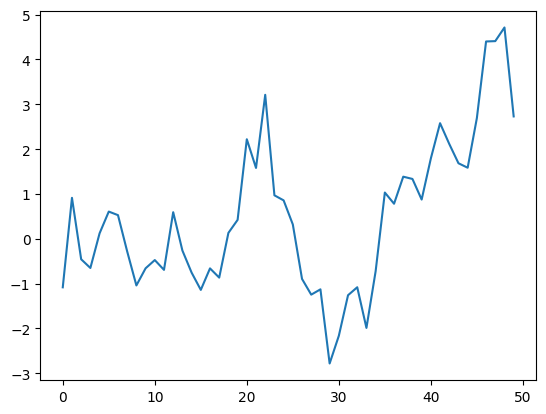

In [ ]:
plt.plot(cum_sum);

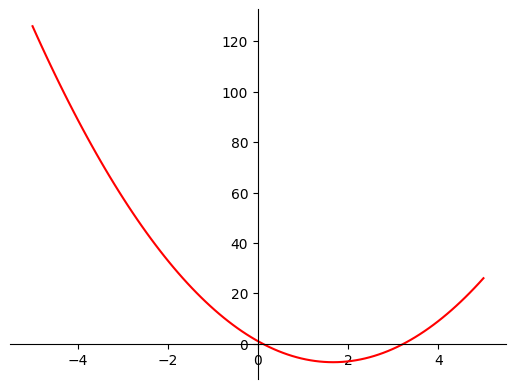

In [ ]:
# 100 linearly spaced numbers
x = np.linspace(-5,5,100)

y = 3* x**2 - 10 * x +1

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.spines['left'].set_position('center')
ax.spines['bottom'].set_position('zero')
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

plt.plot(x,y, 'r')
plt.show()

## 🌶️ Quadratic equation revisited

The code below shows you how to use an existing funciton from the Numpy package to solve a quadratic equation.

test the code forthis equation: $2 x^2+10 x-12=0$

(a = 2, b = 10 and c = -12)

In [43]:
import matplotlib.pyplot as plt
import numpy as np

In [44]:
a = float(input('Enter a: '))
b = float(input('Enter b: '))
c = float(input('Enter c: '))

np.roots([a,b,c])

array([-1.+1.41421356j, -1.-1.41421356j])

In [45]:
def f(a,b,c,x):
    return a * x * x + b * x + c


f(a,b,c,2)

110.0

From the Numpy package, use the linspace() function to create a list of numbers from a to b.

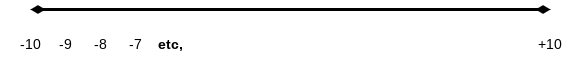

For instance, you can create 21 values between -10 and 10 using the code below:

In [46]:
# 50 linearly spaced numbers
x = np.linspace(-10,10,21)
x

array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
         1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.])

You can then create plots for a chart by calculating the value of f(x) for all points defined in your range.

In [47]:
y = f(a,b,c,x)

print("The values of f(x) are: ",y)


The values of f(x) are:  [ 830.  660.  510.  380.  270.  180.  110.   60.   30.   20.   30.   60.
  110.  180.  270.  380.  510.  660.  830. 1020. 1230.]


And finally, you can use the Matplotlib package to plot your equation.

NOTE: we will cover visualization in more details in week 4.

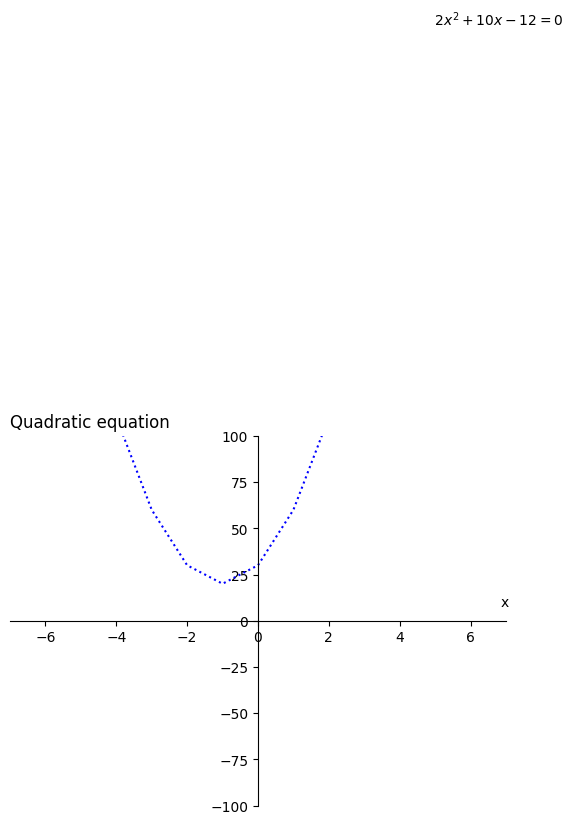

In [48]:
# setting the axes at the centre
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

ax.spines['left'].set_position('center')
ax.spines['bottom'].set_position('center')

ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')

ax.xaxis.set_ticks_position('bottom')
ax.yaxis.set_ticks_position('left')

plt.ylim(-100, 100)
plt.xlim(-7,7)

plt.xlabel("x")
ax.xaxis.set_label_coords(0.998,0.57)

plt.text(4.5, f(a,b,c,4.5), '    $2 x^2+10 x-12=0$')

# plot the quadratic function
plt.plot(x,y, 'b:')

plt.title("Quadratic equation", loc = 'left')

plt.show();